# Лаб 1 — BFS, DFS, Greedy Best-First, A*

Grid World орчинд дөрвөн хайлтын алгоритмыг хэрэгжүүлж харьцуулсан тэмдэглэл.

## 1. Орчин шалгах

In [1]:
import sys, platform
import numpy, pandas, matplotlib

print('Python  :', sys.version.split()[0])
print('Platform:', platform.platform())
print('numpy   :', numpy.__version__)
print('pandas  :', pandas.__version__)
print('mpl     :', matplotlib.__version__)

Python  : 3.13.13
Platform: Linux-6.19.14-108.fc42.x86_64-x86_64-with-glibc2.41
numpy   : 2.5.3
pandas  : 3.0.6
mpl     : 3.11.2


## 2. Grid World

In [2]:
from grid_world import GridWorld

grid = GridWorld([
    ['S', '.', '.', '#', '.'],
    ['#', '.', '.', '#', '.'],
    ['.', '.', '#', '.', '.'],
    ['.', '#', '.', '.', '.'],
    ['.', '.', '.', '#', 'G'],
])

print('start:', grid.start, ' goal:', grid.goal)
for row in grid.grid:
    print(' '.join(row))

start: (0, 0)  goal: (4, 4)
S . . # .
# . . # .
. . # . .
. # . . .
. . . # G


In [3]:
# хөрш нүднүүд: (мөр, багана, өртөг)
print('neighbors of (0,0):', list(grid.neighbors((0, 0))))
print('neighbors of (2,1):', list(grid.neighbors((2, 1))))

neighbors of (0,0): [(0, 1, 1.0)]
neighbors of (2,1): [(1, 1, 1.0), (2, 0, 1.0)]


## 3. Дөрвөн алгоритм — 5×5 grid дээрх үр дүн

In [4]:
import time, statistics
import pandas as pd
from search import bfs, dfs, gbfs, astar, manhattan, euclidean, chebyshev, zero

algos = [
    ('BFS',            lambda g: bfs(g)),
    ('DFS',            lambda g: dfs(g)),
    ('GBFS',           lambda g: gbfs(g, manhattan)),
    ('A* (Manhattan)', lambda g: astar(g, manhattan)),
    ('A* (Euclidean)', lambda g: astar(g, euclidean)),
    ('A* (Chebyshev)', lambda g: astar(g, chebyshev)),
]

rows = []
for name, fn in algos:
    ts = []
    for _ in range(200):
        t0 = time.perf_counter()
        res = fn(grid)
        ts.append((time.perf_counter() - t0) * 1000)
    rows.append({'Algorithm': name, 'Found': res.found, 'Path length': res.path_length,
                 'Cost': round(res.total_cost, 2), 'Visited': res.visited_count,
                 'Expanded': res.expanded, 'Frontier peak': res.frontier_peak,
                 'Time (ms)': round(statistics.median(ts), 3)})

df = pd.DataFrame(rows)
print(df.to_string(index=False))

     Algorithm  Found  Path length  Cost  Visited  Expanded  Frontier peak  Time (ms)
           BFS   True           12  12.0       17        17              3      0.019
           DFS   True           12  12.0       15        15              3      0.017
          GBFS   True           12  12.0       15        15              3      0.022
A* (Manhattan)   True           12  12.0       15        15              3      0.022
A* (Euclidean)   True           12  12.0       15        15              3      0.023
A* (Chebyshev)   True           12  12.0       15        15              3      0.022


## 4. Замыг grid дээр харуулах

In [5]:
def show_path(grid_obj, path):
    out = [row[:] for row in grid_obj.grid]
    for r, c in path:
        if out[r][c] not in ('S', 'G'):
            out[r][c] = '*'
    return '\n'.join(' '.join(row) for row in out)

for name, fn in [('BFS', bfs), ('DFS', dfs),
                 ('GBFS', lambda g: gbfs(g, manhattan)),
                 ('A*', lambda g: astar(g, manhattan))]:
    res = fn(grid)
    print(f'{name}  (урт={res.path_length}, visited={res.visited_count})')
    print(show_path(grid, res.path))
    print()

BFS  (урт=12, visited=17)
S * . # .
# * . # .
* * # . .
* # * * *
* * * # G

DFS  (урт=12, visited=15)
S * . # .
# * . # .
* * # . .
* # * * *
* * * # G

GBFS  (урт=12, visited=15)
S * . # .
# * . # .
* * # . .
* # * * *
* * * # G

A*  (урт=12, visited=15)
S * . # .
# * . # .
* * # . .
* # * * *
* * * # G



## 5. Heuristic-ийн харьцуулалт

`zero` heuristic ашиглавал A* нь BFS-тэй ижил болно.

In [6]:
for h in (manhattan, euclidean, chebyshev, zero):
    r = astar(grid, h)
    print(f'{h.__name__:10s} path={r.path_length:3d}  visited={r.visited_count:3d}')

print()
print('A*(zero) == BFS:', astar(grid, zero).path_length == bfs(grid).path_length)

manhattan  path= 12  visited= 15
euclidean  path= 12  visited= 15
chebyshev  path= 12  visited= 15
zero       path= 12  visited= 17

A*(zero) == BFS: True


## 6. Benchmark — 5×5-аас 25×25 хүртэл

Хэмжээ бүрт seed 0–9 буюу 10 удаа туршиж дундажийг авна.

In [7]:
from benchmark import run, SIZES, ALGOS

visited, times, costs, solvable = run()

bench = pd.DataFrame({'Grid': [f'{n}x{n}' for n in SIZES]})
for a in ALGOS:
    bench[f'{a} visited'] = [round(v, 1) for v in visited[a]]
print(bench.to_string(index=False))
print()
print('Зам олдсон grid-ийн тоо (10-аас):', dict(zip(SIZES, solvable)))

 Grid  BFS visited  DFS visited  GBFS visited  A* visited
  5x5         19.2         13.4           9.8        18.0
10x10         75.5         52.3          21.3        62.5
15x15        168.2        119.8          45.4       134.0
20x20        286.5        140.2          56.6       180.9
25x25        459.8        188.5          62.0       304.5

Зам олдсон grid-ийн тоо (10-аас): {5: 8, 10: 6, 15: 5, 20: 8, 25: 4}


In [8]:
cost_df = pd.DataFrame({'Grid': [f'{n}x{n}' for n in SIZES]})
for a in ALGOS:
    cost_df[f'{a} cost'] = [round(c, 1) for c in costs[a]]
print(cost_df.to_string(index=False))
print()
print('BFS ба A* ижил өртөгтэй юу?',
      all(abs(b - a) < 1e-9 for b, a in zip(costs['BFS'], costs['A*'])))

 Grid  BFS cost  DFS cost  GBFS cost  A* cost
  5x5       8.0       9.0        8.0      8.0
10x10      18.0      24.3       18.7     18.0
15x15      28.0      36.8       32.4     28.0
20x20      39.2      83.0       45.0     39.2
25x25      48.5     114.0       53.5     48.5

BFS ба A* ижил өртөгтэй юу? True


## 7. График

saved -> results/comparison.png


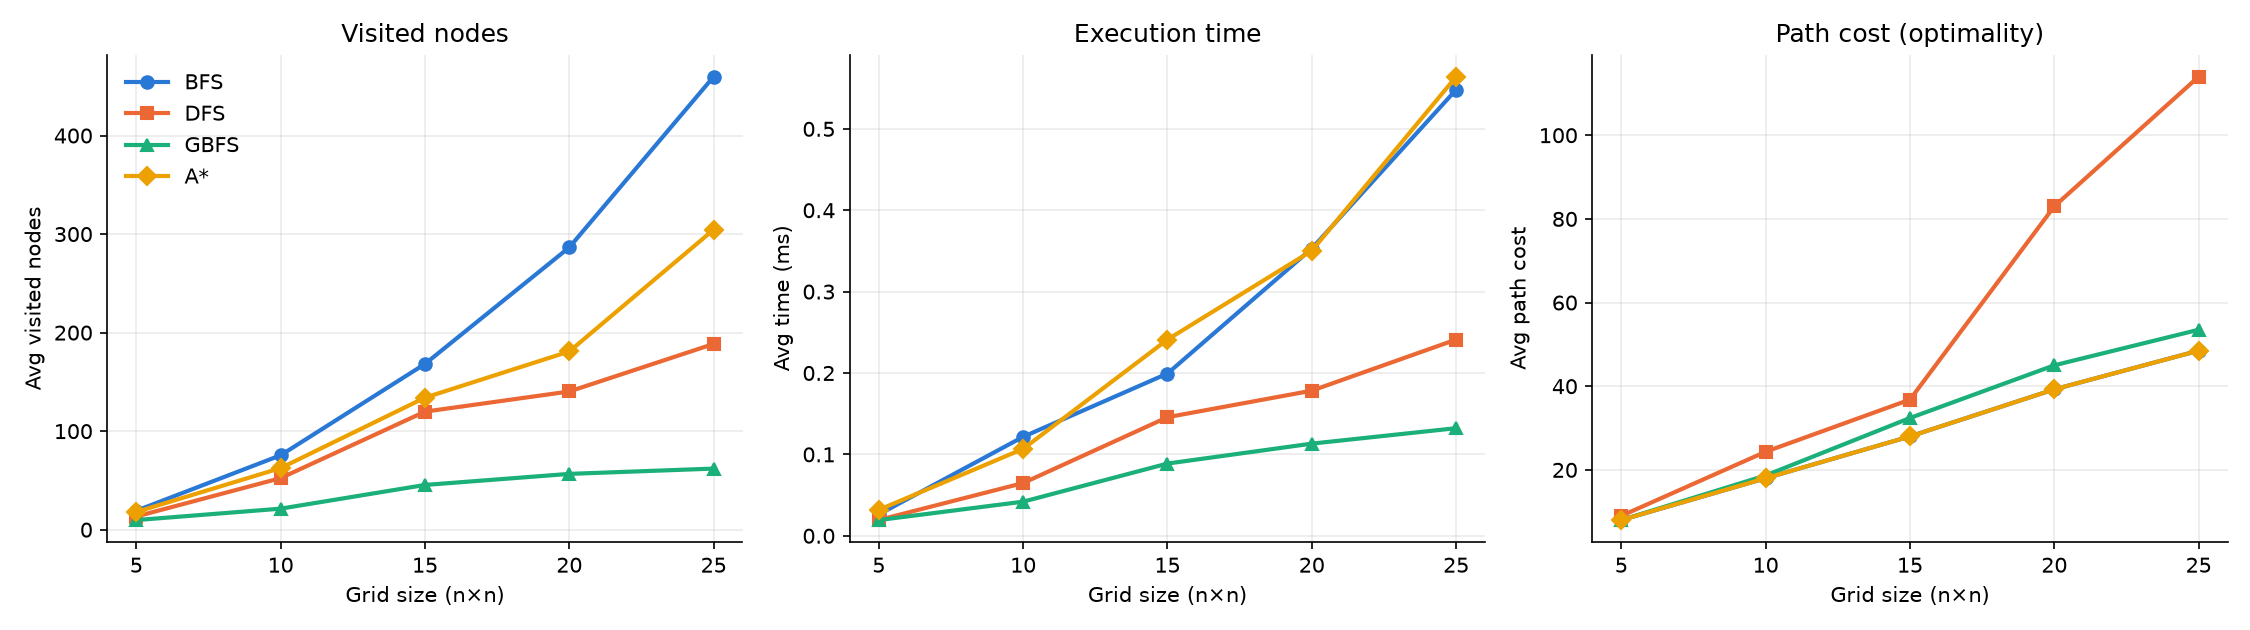

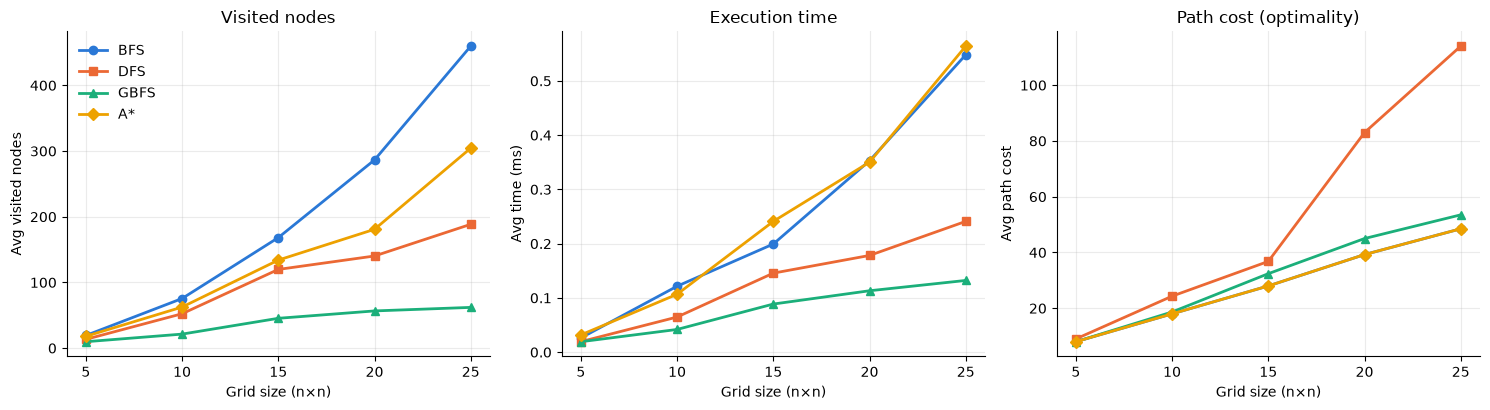

In [9]:
%matplotlib inline
import os
from benchmark import plot
from IPython.display import Image, display

os.makedirs('results', exist_ok=True)
path = plot(visited, times, costs)
print('saved ->', path)
display(Image(filename=path))

## 8. Дүгнэлт

- **BFS ба A\*** бүх хэмжээнд ижил урттай зам олсон — Manhattan heuristic admissible тул A\* optimal.
- **A\*** нь BFS-ээс 34% цөөн зангилаа шалгасан (25×25 дээр 305 vs 460).
- **GBFS** хамгийн цөөн зангилаа шалгасан (62) боловч зам нь optimal-аас ~10% урт.
- **DFS** хамгийн урт замыг өгсөн (BFS-ээс 2.35 дахин).
- Жижиг grid дээр ялгаа мэдэгдэхгүй; хэмжээ өсөх үед heuristic-ийн ач холбогдол харагдана.